# Proyecto de programación
- Marco López
- Federico Cerezo
- Emilio de la Plaza



In [1]:

!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 27.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import time

# Sesión global para las peticiones HTTP
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0 (compatible; PokemonScraper/2.0)"
})

# Cachés para evitar peticiones repetidas a PokeAPI
cache_pokemon = {}
cache_moves = {}

def normalizar_nombre(nombre: str) -> str:
    """
    Normaliza el nombre de un Pokémon para poder usarlo en URLs y en la API.

    Parámetros:
        nombre (str): Nombre original del Pokémon.

    Devuelve:
        str: Nombre en minúsculas, con guiones y sin acentos ni eñes.
    """
    return (nombre.strip().lower()
            .replace(" ", "-")
            .replace("é", "e")
            .replace("á", "a")
            .replace("í", "i")
            .replace("ó", "o")
            .replace("ú", "u")
            .replace("ñ", "n"))

def extraer_estadisticas_pokemon(url):
    """
    Extrae las estadísticas base de un Pokémon desde su página de Wikidex.

    Parámetros:
        url (str): URL de la ficha del Pokémon en Wikidex.

    Devuelve:
        dict: Diccionario con las claves "PS", "Ataque", "Defensa" y "At.Esp".
              Si alguna estadística no se encuentra, su valor será None.
    """
    stats = {"PS": None, "Ataque": None, "Defensa": None, "At.Esp": None}
    try:
        r = SESSION.get(url, timeout=15)
        soup = BeautifulSoup(r.text, "html.parser")
        for tabla in soup.find_all("table", {"class": "tabpokemon"}):
            if "PS" in tabla.get_text():
                for fila in tabla.find_all("tr"):
                    th, td = fila.find("th"), fila.find("td")
                    if not th or not td:
                        continue
                    label = th.get_text(strip=True)
                    valor = td.get_text(strip=True)
                    if valor.isdigit():
                        v = int(valor)
                        if label.startswith("PS"):
                            stats["PS"] = v
                        elif label.startswith("Ataque"):
                            stats["Ataque"] = v
                        elif label.startswith("Defensa") and not label.startswith("Def."):
                            stats["Defensa"] = v
                        elif "At. esp" in label or "At. Esp" in label:
                            stats["At.Esp"] = v
                break
    except:
        pass
    return stats

def obtener_max_potencia_electrica(nombre_pokemon: str):
    """
    Obtiene la potencia máxima de los movimientos de tipo eléctrico
    aprendidos por nivel de un Pokémon usando PokeAPI.

    Parámetros:
        nombre_pokemon (str): Nombre del Pokémon (en español).

    Devuelve:
        int o None: Potencia máxima de un movimiento eléctrico aprendido por nivel,
                    o None si no se encuentra ningún movimiento eléctrico válido.
    """
    api_name = normalizar_nombre(nombre_pokemon)
    url = f"https://pokeapi.co/api/v2/pokemon/{api_name}"

    if api_name in cache_pokemon:
        pdata = cache_pokemon[api_name]
    else:
        try:
            r = SESSION.get(url, timeout=15)
            if r.status_code != 200:
                return None
            pdata = r.json()
            cache_pokemon[api_name] = pdata
        except:
            return None

    max_power = None

    for mv in pdata.get("moves", []):
        if not any((d.get("move_learn_method", {}).get("name") == "level-up")
                   for d in mv.get("version_group_details", [])):
            continue

        move_url = mv["move"]["url"]

        if move_url in cache_moves:
            power, mtype = cache_moves[move_url]
        else:
            try:
                r2 = SESSION.get(move_url, timeout=10)
                if r2.status_code != 200:
                    continue
                data = r2.json()
                power = data.get("power")
                mtype = (data.get("type") or {}).get("name")
                cache_moves[move_url] = (power, mtype)
            except:
                continue

        if mtype == "electric" and isinstance(power, int):
            if (max_power is None) or (power > max_power):
                max_power = power

    return max_power

def lista_pokemons_electricos():
    """
    Obtiene todos los Pokémon de tipo eléctrico desde Wikidex
    y calcula una métrica de poder ofensivo para cada uno.

    La métrica 'Poder' se define como:
        Poder = At.Esp * potencia máxima de un movimiento eléctrico por nivel.

    Devuelve:
        list: Lista de diccionarios con las claves:
              "nombre", "tipos", "PS", "Ataque", "Defensa", "At.Esp" y "Poder".
    """
    url = 'https://www.wikidex.net/wiki/Tipo_el%C3%A9ctrico'
    base = 'https://www.wikidex.net'
    try:
        r = SESSION.get(url, timeout=20)
    except Exception as e:
        print(f"Error al conectar con Wikidex: {e}")
        return []

    soup = BeautifulSoup(r.text, "html.parser")
    bloques = soup.find_all('div', class_='float-app cntpad theme-wiki border-theme center-text')

    pokemons = []

    for bloque in bloques:
        nombre_tag = bloque.find('a')
        if not nombre_tag:
            continue

        nombre = nombre_tag.text.strip()
        link = urljoin(base, nombre_tag.get('href'))

        tipos = [
            t.get("title").replace("Tipo ", "")
            for t in bloque.find_all('a', title=lambda t: t and t.startswith("Tipo"))
        ]

        stats = extraer_estadisticas_pokemon(link)
        max_power = obtener_max_potencia_electrica(nombre)

        if stats["At.Esp"] and max_power:
            poder = stats["At.Esp"] * max_power
        else:
            poder = None

        pokemons.append({
            "nombre": nombre,
            "tipos": tipos,
            "PS": stats["PS"],
            "Ataque": stats["Ataque"],
            "Defensa": stats["Defensa"],
            "At.Esp": stats["At.Esp"],
            "Poder": poder
        })

        time.sleep(0.15)

    return pokemons

def seleccionar_equipo_por_tipos(pokemons_def, pokemons_of):
    """
    Selecciona un equipo final de hasta 6 Pokémon combinando dos listas
    (defensivos y ofensivos) y buscando cubrir el mayor número posible de tipos.

    Primero intenta añadir Pokémon que aporten tipos nuevos y,
    si todavía no hay 6, rellena con el resto de candidatos.

    Parámetros:
        pokemons_def (list): Lista de Pokémon defensivos.
        pokemons_of (list): Lista de Pokémon ofensivos.

    Devuelve:
        tuple: (equipo_final, tipos_cubiertos)
            - equipo_final (list): Lista de Pokémon seleccionados.
            - tipos_cubiertos (set): Conjunto de tipos distintos del equipo.
    """
    combinados = pokemons_def + pokemons_of
    vistos = set()
    todos = []

    for p in combinados:
        if p["nombre"] not in vistos:
            todos.append(p)
            vistos.add(p["nombre"])

    equipo_final = []
    tipos_cubiertos = set()

    for p in todos:
        nuevos_tipos = set(p["tipos"]) - tipos_cubiertos
        if nuevos_tipos:
            equipo_final.append(p)
            tipos_cubiertos.update(p["tipos"])
        if len(equipo_final) >= 6:
            break

    if len(equipo_final) < 6:
        for p in todos:
            if p not in equipo_final:
                equipo_final.append(p)
            if len(equipo_final) >= 6:
                break

    return equipo_final, tipos_cubiertos

pokemons = lista_pokemons_electricos()

# Selección de equipos defensivo y ofensivo a partir de las estadísticas
pokemons_validos_def = [p for p in pokemons if p["Defensa"] and p["PS"] and p["Ataque"]]
equipo_defensivo = sorted(
    pokemons_validos_def,
    key=lambda p: (p["Defensa"], p["PS"], p["Ataque"]),
    reverse=True)[:6]

pokemons_validos_of = [p for p in pokemons if p["At.Esp"] and p["Ataque"] and p["Poder"]]
equipo_ofensivo = sorted(
    pokemons_validos_of,
    key=lambda p: (p["At.Esp"], p["Ataque"], p["Poder"]),
    reverse=True)[:6]

# Mostrar ambos equipos
print("\n EQUIPO DEFENSIVO (Top 6)\n")
for i, p in enumerate(equipo_defensivo, 1):
    print(f"{i}. {p['nombre']} | Defensa: {p['Defensa']} | PS: {p['PS']} | Ataque: {p['Ataque']}")

print("\n EQUIPO OFENSIVO (Top 6)\n")
for i, p in enumerate(equipo_ofensivo, 1):
    print(f"{i}. {p['nombre']} | At.Esp: {p['At.Esp']} | Ataque: {p['Ataque']} | Poder: {p['Poder']}")

# Equipo final por tipos
equipo_final, tipos_cubiertos = seleccionar_equipo_por_tipos(equipo_defensivo, equipo_ofensivo)
print("\n EQUIPO FINAL POR TIPOS\n")
print(f"Tipos distintos cubiertos: {len(tipos_cubiertos)} ({', '.join(tipos_cubiertos)})\n")
for i, p in enumerate(equipo_final, 1):
    print(f"{i}. {p['nombre']} | Tipos: {', '.join(p['tipos'])}")


 EQUIPO DEFENSIVO (Top 6)

1. Golem | Defensa: 130 | PS: 80 | Ataque: 120
2. Omastar | Defensa: 125 | PS: 70 | Ataque: 60
3. Arceus | Defensa: 120 | PS: 120 | Ataque: 120
4. Zekrom | Defensa: 120 | PS: 100 | Ataque: 150
5. Magnezone | Defensa: 115 | PS: 70 | Ataque: 70
6. Graveler | Defensa: 115 | PS: 55 | Ataque: 95

 EQUIPO OFENSIVO (Top 6)

1. Xurkitree | At.Esp: 173 | Ataque: 89 | Poder: 20760
2. Vikavolt | At.Esp: 145 | Ataque: 70 | Poder: 17400
3. Miraidon | At.Esp: 135 | Ataque: 85 | Poder: 14850
4. Porygon-Z | At.Esp: 135 | Ataque: 80 | Poder: 16200
5. Magnezone | At.Esp: 130 | Ataque: 70 | Poder: 15600
6. Zapdos | At.Esp: 125 | Ataque: 90 | Poder: 15000

 EQUIPO FINAL POR TIPOS

Tipos distintos cubiertos: 6 (dragón, eléctrico, acero, volador, bicho, roca)

1. Golem | Tipos: roca, eléctrico
2. Zekrom | Tipos: dragón, eléctrico
3. Magnezone | Tipos: eléctrico, acero
4. Vikavolt | Tipos: bicho, eléctrico
5. Zapdos | Tipos: eléctrico, volador
6. Omastar | Tipos: eléctrico


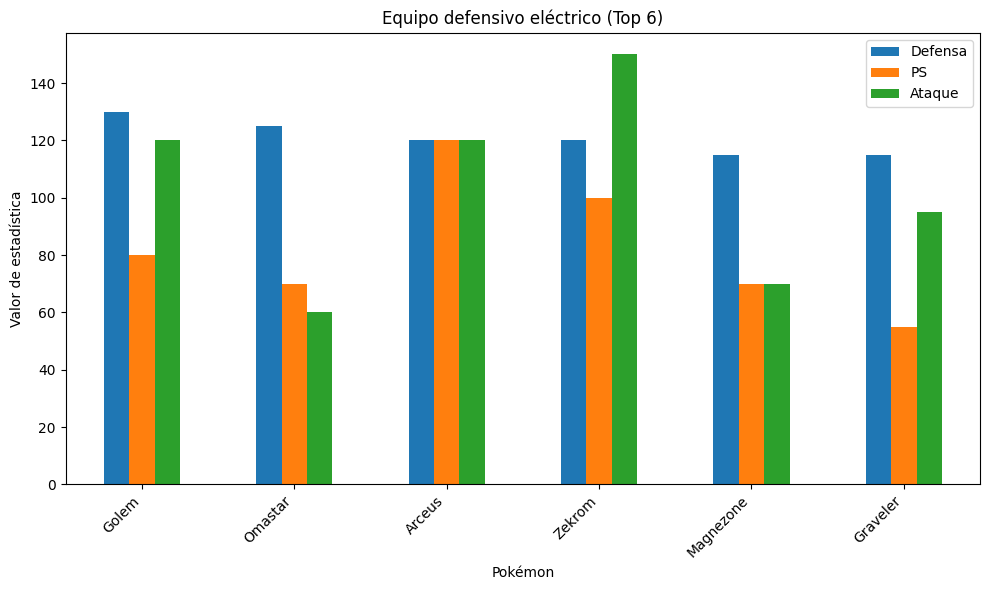

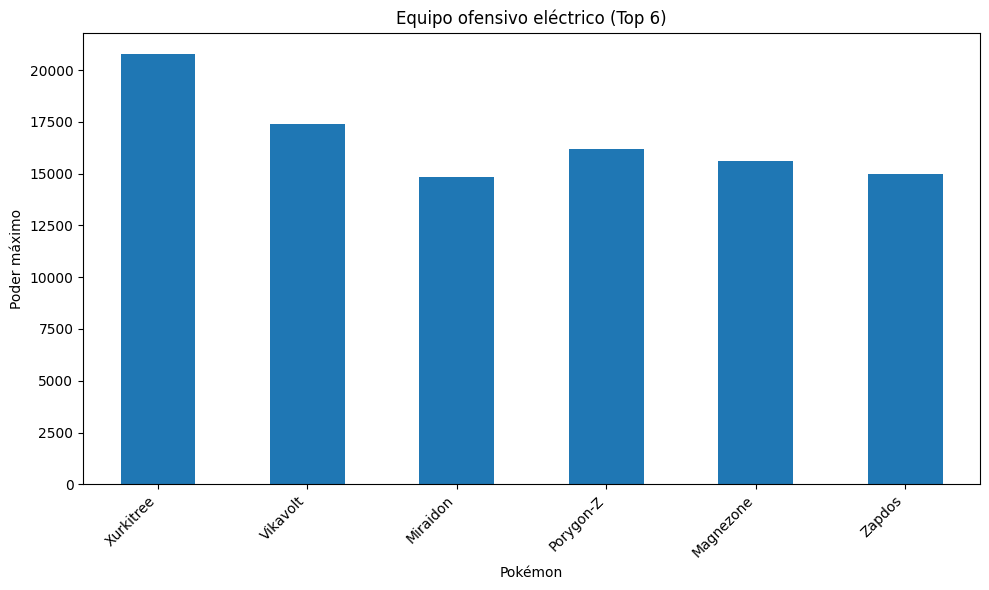

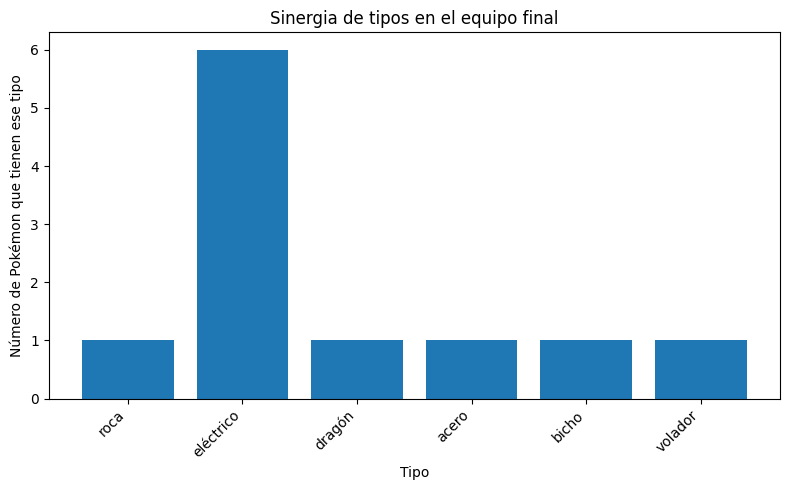

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Gráfica equipo defensivo
df_def = pd.DataFrame(equipo_defensivo)

cols_def = ["nombre", "Defensa", "PS", "Ataque"]
df_def = df_def[cols_def]

df_def_plot = df_def.set_index("nombre")

ax = df_def_plot[["Defensa", "PS", "Ataque"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Equipo defensivo eléctrico (Top 6)")
plt.ylabel("Valor de estadística")
plt.xlabel("Pokémon")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Gráfica equipo ofensivo
df_of = pd.DataFrame(equipo_ofensivo)

cols_of = ["nombre", "At.Esp", "Ataque", "Poder"]
df_of = df_of[cols_of]

df_of_plot = df_of.set_index("nombre")

ax = df_of_plot["Poder"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Equipo ofensivo eléctrico (Top 6)")
plt.ylabel("Poder máximo")
plt.xlabel("Pokémon")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Gráfica sinergia de tipos
all_types = []
for p in equipo_final:
    all_types.extend(p["tipos"])

# Frecuencia de tipos
counter_types = Counter(all_types)

tipos = list(counter_types.keys())
frecuencias = list(counter_types.values())

# Barras de tipos
plt.figure(figsize=(8, 5))
plt.bar(tipos, frecuencias)

plt.title("Sinergia de tipos en el equipo final")
plt.ylabel("Número de Pokémon que tienen ese tipo")
plt.xlabel("Tipo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [4]:

import re
import requests
import pandas as pd
from bs4 import BeautifulSoup

# Scraping de movimientos
url="https://www.wikidex.net/wiki/Lista_de_movimientos"

def extraer_nombre(celda):
    """
    Extrae el nombre del movimiento desde una celda HTML.
    Intenta obtener la versión en español si existe.
    Parámetros:
        celda: Objeto HTML donde se encuentra el nombre.
    Devuelve:
        str: Nombre del movimiento en texto plano.
    """
    span_es = celda.find("span", attrs={"lang": "es-ES"})
    if span_es:
        return span_es.text.strip()
    a_tag = celda.find("a")
    if a_tag:
        return a_tag.text.strip()
    return celda.get_text(strip=True)

def extraer_potencia(celda):
    """
    Extrae la potencia de un movimiento desde la celda correspondiente.
    Tiene en cuenta casos como 'Varía', valores dentro de data-sort,
    números con referencias y otros formatos atípicos.
    Parámetros:
        celda: Celda HTML donde aparece la potencia del movimiento.
    Devuelve:
        str: Potencia limpia del movimiento.
    """
    if "Varía" in celda.get_text():
        return "Varía"
    if celda.has_attr("data-sort-value"):
        return celda["data-sort-value"]
    for sup in celda.find_all("sup"):
        sup.decompose()
    texto = celda.get_text(strip=True)
    if texto.isdigit():
        return texto
    match = re.match(r"(\d+)", texto)
    if match:
        return match.group(1)
    return texto

def extraer_movimientos(url):
    """
    Extrae todos los movimientos desde la tabla principal de Wikidex
    y los clasifica como ofensivos o defensivos según la potencia.
    Parámetros:
        url (str): URL de la lista de movimientos en Wikidex.
    Devuelve:
        tuple: (df, dfn)
            df: DataFrame con los movimientos válidos.
            dfn: DataFrame con movimientos descartados y su motivo.
    """
    res = requests.get(url)
    soup = BeautifulSoup(res.text, "html.parser")
    table = soup.find("table", {"class": "tabpokemon"})
    rows = table.find_all("tr")[1:]
    moves = []
    mov_no_validos = []
    for row in rows:
        cols = row.find_all("td")
        if len(cols) < 7:
            Id_mov = cols[0].text.strip()[:4] if len(cols) > 0 else None
            mov_no_validos.append({"ID_movimiento": Id_mov, "motivo": "filas incompletas"})
        else:
            Id_mov = cols[0].text.strip()
            nombre = extraer_nombre(cols[1])
            descripcion = cols[3].text.strip()
            potencia = extraer_potencia(cols[6])
            if descripcion == "-":
                mov_no_validos.append({"ID_movimiento": Id_mov, "motivo": "descripcion inválida"})
            else:
                clase = "defensivo" if potencia == "-" else "ofensivo"
                moves.append({
                    "ID_movimiento": Id_mov,
                    "nombre": nombre,
                    "potencia": potencia,
                    "descripcion": descripcion,
                    "clase": clase
                })
    df = pd.DataFrame(moves)
    dfn = pd.DataFrame(mov_no_validos)
    return df, dfn

df, dfn = extraer_movimientos(url)

print("Total de movimientos encontrados:", len(df))
print(df.head(10))

# Balancear dataset
import numpy as np
import spacy

def crear_dataset_equilibrado(df):
    """
    Equilibra el número de ejemplos ofensivos y defensivos
    seleccionando la misma cantidad de cada clase.
    Parámetros:
        df (DataFrame): Dataset original con la columna 'clase'.
    Devuelve:
        DataFrame: Dataset equilibrado y mezclado.
    """
    df_of = df[df["clase"]=="ofensivo"]
    df_def = df[df["clase"]=="defensivo"]
    min_len = min(len(df_of), len(df_def))
    df_of = df_of.sample(n=min_len, random_state=42)
    df_def = df_def.sample(n=min_len, random_state=42)
    df_equilibrado = pd.concat([df_of, df_def]).sample(frac=1, random_state=42).reset_index(drop=True)
    return df_equilibrado
df_equilibrado = crear_dataset_equilibrado(df)
print(f"Dataset equilibrado: {len(df_equilibrado)} ejemplos")

# Preprocesamiento NLP
nlp = spacy.load("es_core_news_sm")

def text_to_tokens(text):
    """
    Convierte un texto a una lista de tokens lematizados,
    filtrando stopwords y símbolos.
    """
    doc = nlp(text)
    return [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]

def text_to_vector(text, vocab):
    """
    Convierte un texto en un vector numérico usando frecuencias
    de palabras basadas en el vocabulario generado.
    """
    tokens = text_to_tokens(text)
    counter = {w: tokens.count(w) for w in vocab}
    total = sum(counter.values())
    return [counter[w]/total if total > 0 else 0 for w in vocab]

all_words = [t for desc in df_equilibrado["descripcion"] for t in text_to_tokens(desc)]
vocab = list(pd.Series(all_words).value_counts().keys())
X = np.array([text_to_vector(d, vocab) for d in df_equilibrado["descripcion"]])
y = df_equilibrado["clase"].values

# Entrenamiento ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n--- Modelo NLP entrenado ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Total de movimientos encontrados: 896
  ID_movimiento         nombre potencia  \
0          0001     Destructor       40   
1          0002   Golpe kárate       50   
2          0003  Doble bofetón       15   
3          0004    Puño cometa       18   
4          0005       Megapuño       80   
5          0006    Día de pago       40   
6          0007     Puño fuego       75   
7          0008     Puño hielo       75   
8          0009    Puño trueno       75   
9          0010        Arañazo       40   

                                         descripcion     clase  
0  Golpea al objetivo con las extremidades, la co...  ofensivo  
1           Da un golpe cortante. Suele ser crítico.  ofensivo  
2            Abofetea de dos a cinco veces seguidas.  ofensivo  
3                Pega de dos a cinco veces seguidas.  ofensivo  
4                         Puñetazo de gran potencia.  ofensivo  
5  Ataca al objetivo arrojándole monedas. Al fina...  ofensivo  
6     Puñetazo ardiente que puede

In [5]:
import time
import re
from urllib.parse import urljoin
import pandas as pd
from bs4 import BeautifulSoup

if 'equipo_final' not in globals():
    raise RuntimeError("La variable 'equipo_final' no existe. Ejecuta la CELDA 1 primero.")

if 'df' not in globals():
    raise RuntimeError("La variable 'df' no existe. Ejecuta la CELDA 2 primero.")

BASE_WIKIDEX = 'https://www.wikidex.net/wiki/'

def _normalizar_para_url(nombre):
    """
    Genera varias posibles formas de una URL de Pokémon a partir de su nombre.

    Parámetros:
        nombre (str): Nombre del Pokémon.

    Devuelve:
        list: Lista de variantes de URL (sin dominio) para probar en Wikidex.
    """
    nm = nombre.strip()
    nm_ascii = (nm.replace(' ', '_')
                 .replace('é', 'e').replace('á', 'a')
                 .replace('í', 'i').replace('ó', 'o')
                 .replace('ú', 'u').replace('ñ', 'n'))
    variants = [
        nm.replace(' ', '_'),
        nm.replace(' ', '-'),
        nm_ascii,
        f"{nm.replace(' ', '_')}_(Pokémon)",
        f"{nm_ascii}_(Pokémon)",
        f"{nm.replace(' ', '-') }_(Pokémon)"
    ]
    seen = set()
    out = []
    for v in variants:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out

def extraer_descripcion_movimiento(url):
    """
    Extrae una descripción corta de un movimiento desde su página en Wikidex.

    Parámetros:
        url (str): URL de la página del movimiento.

    Devuelve:
        str o None: Descripción del movimiento, o None si no se encuentra.
    """
    try:
        r = SESSION.get(url, timeout=12)
        if r.status_code != 200:
            return None

        soup = BeautifulSoup(r.text, "html.parser")

        dd = soup.select_one("dl dd")
        if dd:
            return dd.get_text(" ", strip=True)

        p = soup.find("p")
        if p:
            return p.get_text(strip=True)

        return None

    except:
        return None

def extraer_movimientos_equipo(equipo_final, df, BASE_WIKIDEX, SESSION):
    """
    Extrae movimientos por nivel de todos los Pokémon del equipo_final
    usando Wikidex.

    Parámetros:
        equipo_final (list): Lista de diccionarios con la información de cada Pokémon del equipo.
        df (DataFrame): Tabla con información de movimientos (incluye nombre y potencia).
        BASE_WIKIDEX (str): URL base de Wikidex.
        SESSION (requests.Session): Sesión reutilizable para realizar las peticiones HTTP.

    Devuelve:
        df_moves: DataFrame con los movimientos encontrados incluyendo:
                  pokemon (str), movimiento (str), potencia (str), descripcion (str),
                  class (str), move_url (str)
    """

    rows = []

    for pkm in equipo_final:
        nombre = pkm['nombre']
        print(f"[INFO] Procesando: {nombre}")

        # Buscar página del Pokémon
        page_soup = None
        for var in _normalizar_para_url(nombre):
            try:
                url_pokemon = urljoin(BASE_WIKIDEX, var)
                r = SESSION.get(url_pokemon, timeout=12, allow_redirects=True)
                if r.status_code == 200:
                    page_soup = BeautifulSoup(r.text, 'html.parser')
                    break
            except:
                continue

        if not page_soup:
            print(f"  [WARN] No se pudo acceder a {nombre}")
            continue

        for tabla in page_soup.find_all('table'):
            header_text = ' '.join(
                [h.get_text(strip=True) for h in tabla.find_all('th')]
            ).lower()

            # Identificar tabla válida
            if 'nivel' in header_text or re.search(r'\b\d+\b', tabla.get_text()):
                for tr in tabla.find_all('tr'):
                    tds = tr.find_all('td')
                    if not tds:
                        continue

                    first = tds[0].get_text(strip=True)

                    # Fila con nivel (primer número)
                    if re.match(r'^\s*\d+', first):

                        # Buscar primer link válido a movimiento
                        move_link_tag = None
                        for td in tds:
                            a = td.find('a', href=True)
                            if a and '/wiki/' in a['href'] and not a['href'].lower().startswith('/wiki/archivo'):
                                move_link_tag = a
                                break

                        if not move_link_tag:
                            continue

                        move_name = move_link_tag.text.strip()

                        potencia = "-"
                        fila = df[df["nombre"] == move_name]
                        if not fila.empty:
                            potencia = fila.iloc[0]["potencia"]

                        move_url = urljoin(BASE_WIKIDEX, move_link_tag['href'])
                        descripcion = extraer_descripcion_movimiento(move_url)

                        rows.append({
                            'pokemon': nombre,
                            'movimiento': move_name,
                            'potencia': potencia,
                            'descripcion': descripcion,
                            'class': None,
                            'move_url': move_url
                        })
        time.sleep(0.18)

    df_moves = pd.DataFrame(rows)
    return df_moves

df_moves_team = extraer_movimientos_equipo(
    equipo_final=equipo_final,
    df=df,
    BASE_WIKIDEX=BASE_WIKIDEX,
    SESSION=SESSION
)

df_moves_team.head()


[INFO] Procesando: Golem
[INFO] Procesando: Zekrom
[INFO] Procesando: Magnezone
[INFO] Procesando: Vikavolt
[INFO] Procesando: Zapdos
[INFO] Procesando: Omastar


,pokemon,movimiento,potencia,descripcion,class,move_url
0,Golem,Cuerpo pesado,Varía,Golpe pesado / Cuerpo pesado causa daño y no t...,None,https://www.wikidex.net/wiki/Cuerpo_pesado
1,Golem,Placaje,40,Tacleada / Placaje causa daño y no tiene ningú...,None,https://www.wikidex.net/wiki/Placaje
2,Golem,Rizo defensa,-,Evita que el Pokémon sea intimidado en una oca...,None,https://www.wikidex.net/wiki/Rizo_defensa
3,Golem,Pulimento,-,En la siguiente ronda permite exhibirse el pri...,None,https://www.wikidex.net/wiki/Pulimento
4,Golem,Lanzarrocas,50,Lanzarrocas causa daño y no tiene ningún efect...,None,https://www.wikidex.net/wiki/Lanzarrocas


In [6]:
import numpy as np

# Clasificación de los movimientos del equipo usando el modelo NLP entrenado
if 'clf' not in globals() or clf is None:
    raise RuntimeError("\nEl clasificador (clf) no está disponible. Ejecuta la celda del modelo primero.")
if 'df_moves_team' not in globals():
    raise RuntimeError("\nEl DataFrame 'df_moves_team' no está disponible. Ejecuta la celda de movimientos primero.")

# Para cada movimiento, convertir la descripción en vector y obtener la predicción
for idx, row in df_moves_team.iterrows():
    desc = row.get('descripcion') or ''
    if not isinstance(desc, str):
        desc = str(desc)
    try:
        vec = text_to_vector(desc, vocab)
        vec_arr = np.array(vec).reshape(1, -1)
        pred = clf.predict(vec_arr)[0]
    except Exception:
        # Si ocurre algún error de procesamiento, lo marcamos como ofensivo
        pred = 'ofensivo'
    df_moves_team.at[idx, 'class'] = pred

print("\nMovimientos con clase asignada (muestra):")
print(df_moves_team.head(20))


Movimientos con clase asignada (muestra):
   pokemon        movimiento potencia  \
0    Golem     Cuerpo pesado    Varía   
1    Golem           Placaje       40   
2    Golem      Rizo defensa        -   
3    Golem         Pulimento        -   
4    Golem       Lanzarrocas       50   
5    Golem         Antiaéreo       50   
6    Golem      Terratemblor       60   
7    Golem   Autodestrucción      200   
8    Golem      Trampa rocas        -   
9    Golem           Pedrada       25   
10   Golem         Terremoto      100   
11   Golem         Explosión      250   
12   Golem        Doble filo      120   
13   Golem      Roca afilada      100   
14  Zekrom      Dragoaliento       60   
15  Zekrom      Poder pasado       60   
16  Zekrom     Colmillo rayo       65   
17  Zekrom  Rugido de guerra        -   
18  Zekrom        Cuchillada       70   
19  Zekrom          Triturar       80   

                                          descripcion      class  \
0   Golpe pesado / Cuerpo p

In [7]:
def seleccionar_mejores_movimientos(df_moves_team, equipo_final):
    """
    Selecciona, para cada Pokémon del equipo final, sus mejores movimientos
    según la clase asignada por el modelo y la potencia.

    Para cada Pokémon:
        - Elige hasta 3 movimientos ofensivos con mayor potencia.
        - Elige 1 movimiento defensivo (si existe).

    Parámetros:
        df_moves_team (DataFrame): Movimientos ya asociados a cada Pokémon.
        equipo_final (list): Lista de Pokémon seleccionados en el equipo.

    Devuelve:
        DataFrame: Conjunto de movimientos seleccionados para todo el equipo.
    """
    filas_finales = []

    for pkm in equipo_final:
        nombre = pkm["nombre"]

        sub = df_moves_team[df_moves_team["pokemon"] == nombre].copy()
        if sub.empty:
            continue

        def pot_to_num(row):
            if row["class"] == "defensivo":
                return None

            p = str(row["potencia"]).strip()
            try:
                return int(p)
            except:
                return 0

        sub["pot_num"] = sub.apply(pot_to_num, axis=1)

        ofensivos = (
            sub[sub["class"] == "ofensivo"]
            .sort_values("pot_num", ascending=False)
            .head(3)
        )

        defensivos = (
            sub[(sub["class"] == "defensivo") & (sub["pot_num"].isna())]
            .head(1)
        )

        filas_finales.append(ofensivos)
        filas_finales.append(defensivos)

    if filas_finales:
        return pd.concat(filas_finales, ignore_index=True)
    else:
        return pd.DataFrame()

df_best_moves = (
    seleccionar_mejores_movimientos(df_moves_team, equipo_final)
    .drop("pot_num", axis=1)
)

In [8]:
import requests
import IPython.display as display
from IPython.display import HTML

def obtener_gif_pokemon(nombre):
    """
    Obtiene el sprite animado (gif) de un Pokémon desde PokeAPI.
    Si no hay animación disponible, usa el sprite frontal normal.

    Parámetros:
        nombre (str): Nombre del Pokémon.

    Devuelve:
        str o None: URL del sprite del Pokémon, o None si no se puede obtener.
    """
    try:
        url = f"https://pokeapi.co/api/v2/pokemon/{nombre.lower()}"
        r = requests.get(url, timeout=10)
        data = r.json()

        gif = data["sprites"]["versions"]["generation-v"]["black-white"]["animated"]["front_default"]
        if gif:
            return gif

        return data["sprites"]["front_default"]

    except:
        return None

def mostrar_equipo(equipo_final, df_best_moves):
    """
    Muestra el equipo final en forma de tarjetas HTML con:
    - Nombre del Pokémon
    - Sprite obtenido de PokeAPI
    - Movimientos seleccionados (ofensivos y defensivos)

    Parámetros:
        equipo_final (list): Lista de Pokémon seleccionados.
        df_best_moves (DataFrame): Movimientos escogidos para cada Pokémon.
    """
    pokemon_cards = ""

    for pkm in equipo_final:
        nombre = pkm["nombre"]
        gif = obtener_gif_pokemon(nombre)

        movs = df_best_moves[df_best_moves["pokemon"] == nombre]

        mov_html = ""
        for _, row in movs.iterrows():
            mov = row["movimiento"]
            pot = row["potencia"]
            clase = row["class"]

            icon = "⚔️" if clase == "ofensivo" else "🛡️"
            potencia = f"{pot}" if clase == "ofensivo" else "—"

            mov_html += f"""
                <div class="move">
                    <span class="mov-name">{mov}</span>
                    <span class="mov-pot">{potencia} {icon}</span>
                </div>
            """

        pokemon_cards += f"""
        <div class="card">
            <h2 class="poke-name">{nombre}</h2>
            <img src="{gif}" class="poke-img">
            <h3 class="moves-title">Movimientos</h3>
            <div class="moves-box">
                {mov_html}
            </div>
        </div>
        """

    html = f"""
    <style>
        .container {{
            display: flex;
            flex-wrap: wrap;
            gap: 25px;
            justify-content: center;
            margin-top: 20px;
        }}
        .card {{
            width: 260px;
            background: linear-gradient(145deg, #fefefe, #e8e8e8);
            border-radius: 18px;
            padding: 20px;
            box-shadow: 0 4px 10px rgba(0,0,0,0.15);
            transition: transform 0.2s ease, box-shadow 0.2s ease;
            color: black;
        }}
        .card:hover {{
            transform: scale(1.05);
            box-shadow: 0 8px 25px rgba(0,0,0,0.25);
        }}
        .poke-name {{
            text-align: center;
            font-family: 'Arial Black';
            letter-spacing: 1px;
            margin-bottom: 8px;
            color: black;
        }}
        .poke-img {{
            display: block;
            margin: 0 auto;
            width: 130px;
            image-rendering: pixelated;
        }}
        .moves-title {{
            margin-top: 15px;
            text-align: center;
            font-size: 18px;
            color: black;
        }}
        .moves-box {{
            background: #ffffffbb;
            border-radius: 12px;
            padding: 10px;
            margin-top: 8px;
            border: 1px solid #ddd;
        }}
        .move {{
            display: flex;
            justify-content: space-between;
            padding: 5px 0;
            border-bottom: 1px solid #eee;
        }}
        .move:last-child {{
            border-bottom: none;
        }}
        .mov-name {{
            font-weight: bold;
        }}
        .mov-pot {{
            opacity: 0.8;
        }}
    </style>

    <h1 style="text-align:center; font-family:Arial; margin-bottom:10px;">Equipo definitivo Pokémon </h1>

    <div class="container">
        {pokemon_cards}
    </div>
    """

    display.display(HTML(html))

mostrar_equipo(equipo_final, df_best_moves)
